# importing library

In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/clinical_trials.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/biotech_funding.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/pharma_companies_financials.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/drug_approvals.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/disease_burden.csv


# loading datasets

In [2]:
clin_trial=pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/clinical_trials.csv")
bio_fund=pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/biotech_funding.csv")
phar_cmpny=pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/pharma_companies_financials.csv")
drug_approv=pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/drug_approvals.csv")
dis_burdn=pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/disease_burden.csv")




dset={
    "clin":clin_trial,
    "bio":bio_fund,
    "phar":phar_cmpny,
    "drug":drug_approv,
    "dis":dis_burdn
}

for name,df in dset.items():
    print(name)
    print(df.columns.to_list())

clin
['trial_id', 'completion_date', 'year', 'sponsor', 'therapy_area', 'phase', 'enrollment_n', 'duration_months', 'outcome', 'is_success', 'is_failure', 'estimated_stock_impact_pct']
bio
['deal_id', 'date', 'year', 'deal_type', 'acquirer_or_investors', 'target_or_company', 'value_usd_bn', 'description', 'is_megadeal', 'is_real_headline']
phar
['year', 'company_name', 'ticker', 'country_iso3', 'segment', 'revenue_usd_bn', 'operating_margin_pct', 'operating_income_usd_bn', 'rd_spend_usd_bn', 'pipeline_size_est']
drug
['approval_id', 'approval_date', 'year', 'drug_name', 'sponsor_company', 'drug_type', 'therapy_area', 'peak_sales_usd_bn_est', 'is_blockbuster', 'is_mega_blockbuster', 'description', 'is_real_headline']
dis
['year', 'region', 'disease', 'dalys_millions', 'global_dalys_millions']


# convert date columns to datetime

In [3]:
drug_approv['approval_date']=pd.to_datetime(drug_approv['approval_date'],errors='coerce')
bio_fund['date']=pd.to_datetime(bio_fund['date'],errors='coerce')
clin_trial['completion_date']=pd.to_datetime(clin_trial['completion_date'],errors="coerce")







# preprocessing step
# counting null values 

In [4]:
for name,df in dset.items():
    print(f"{name} ")
    print(df.isnull().sum())



clin 
trial_id                      0
completion_date               0
year                          0
sponsor                       0
therapy_area                  0
phase                         0
enrollment_n                  0
duration_months               0
outcome                       0
is_success                    0
is_failure                    0
estimated_stock_impact_pct    0
dtype: int64
bio 
deal_id                  0
date                     0
year                     0
deal_type                0
acquirer_or_investors    0
target_or_company        0
value_usd_bn             0
description              0
is_megadeal              0
is_real_headline         0
dtype: int64
phar 
year                       0
company_name               0
ticker                     0
country_iso3               0
segment                    0
revenue_usd_bn             0
operating_margin_pct       0
operating_income_usd_bn    0
rd_spend_usd_bn            0
pipeline_size_est          0
dtype: int64


# cheacking duplicate values

In [5]:
for name,df in dset.items():
    print(f"{name}")
    print(df.duplicated().count())
    

clin
599
bio
1208
phar
489
drug
722
dis
3310


In [6]:
#printing the shapes of every datasets
for name,df in dset.items():
    print(f"{name}")
    print(df.shape)

clin
(599, 12)
bio
(1208, 10)
phar
(489, 10)
drug
(722, 12)
dis
(3310, 5)


# description of every datasets

In [7]:
for name,df in dset.items():
    print(f"{name}")
    print(df.describe())

clin
                     completion_date         year  enrollment_n  \
count                            599   599.000000    599.000000   
mean   2018-02-06 13:10:55.091819776  2017.612688    790.163606   
min              2010-01-05 00:00:00  2010.000000     47.000000   
25%              2013-10-04 12:00:00  2013.000000    244.500000   
50%              2018-02-12 00:00:00  2018.000000    524.000000   
75%              2022-05-25 00:00:00  2022.000000   1112.000000   
max              2026-04-05 00:00:00  2026.000000   4179.000000   
std                              NaN     4.759807    720.689342   

       duration_months  is_success  is_failure  estimated_stock_impact_pct  
count       599.000000  599.000000  599.000000                  599.000000  
mean         27.555927    0.520868    0.325543                   -0.961436  
min           6.000000    0.000000    0.000000                  -41.200000  
25%          18.000000    0.000000    0.000000                   -8.550000  
50%   

# information of every dataset

In [8]:
for name,df in dset.items():
    print(f"{name}")
    print(df.info())

clin
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trial_id                    599 non-null    object        
 1   completion_date             599 non-null    datetime64[ns]
 2   year                        599 non-null    int64         
 3   sponsor                     599 non-null    object        
 4   therapy_area                599 non-null    object        
 5   phase                       599 non-null    object        
 6   enrollment_n                599 non-null    int64         
 7   duration_months             599 non-null    int64         
 8   outcome                     599 non-null    object        
 9   is_success                  599 non-null    int64         
 10  is_failure                  599 non-null    int64         
 11  estimated_stock_impact_pct  599 non-null    float64  

# importing important library for visualization

In [9]:
import matplotlib.pyplot as plt
plt.switch_backend('Agg')
%matplotlib inline
import seaborn as sns

# EDA 

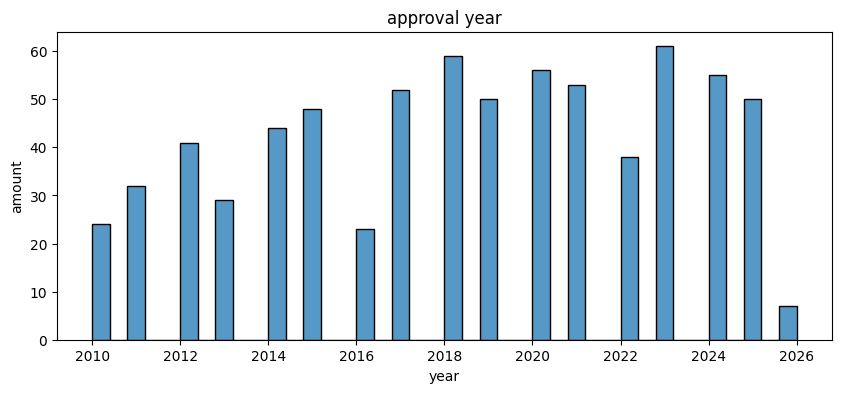

In [10]:
# DRUG APPROVL YEAR
plt.figure(figsize=(10,4))
sns.histplot(drug_approv['year'],bins=40)
plt.title("approval year")
plt.xlabel("year")
plt.ylabel("amount")
plt.show()


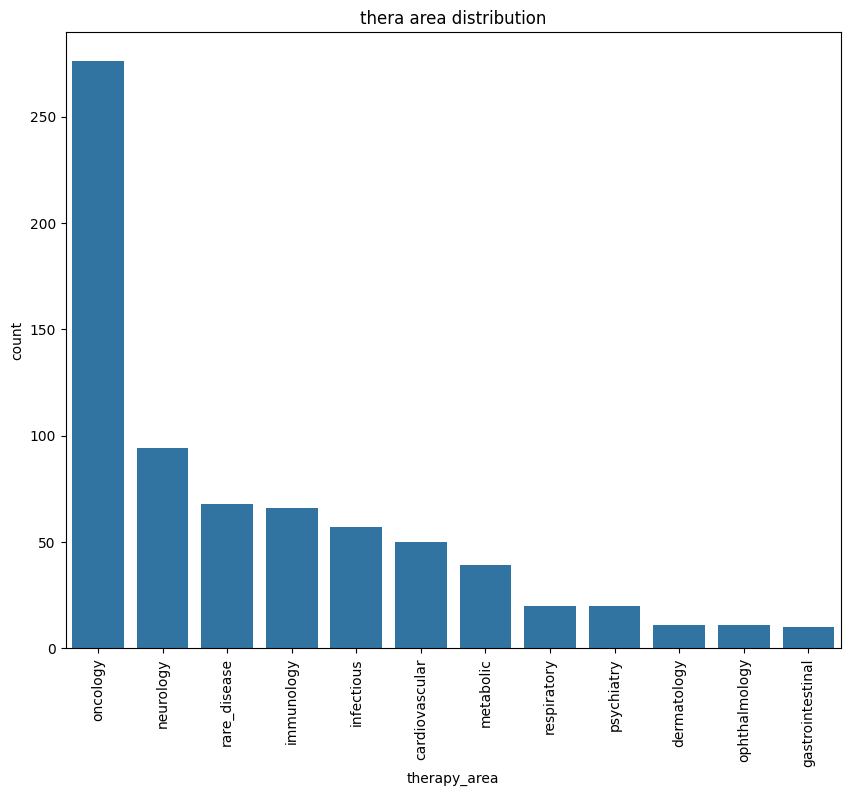

In [11]:
# DRUG APPROVAL THERAPY AREA
plt.figure(figsize=(10,8))
sns.countplot(data=drug_approv,x='therapy_area',order=drug_approv['therapy_area'].value_counts().index)
plt.xticks(rotation=90)
plt.title("thera area distribution")
plt.show()





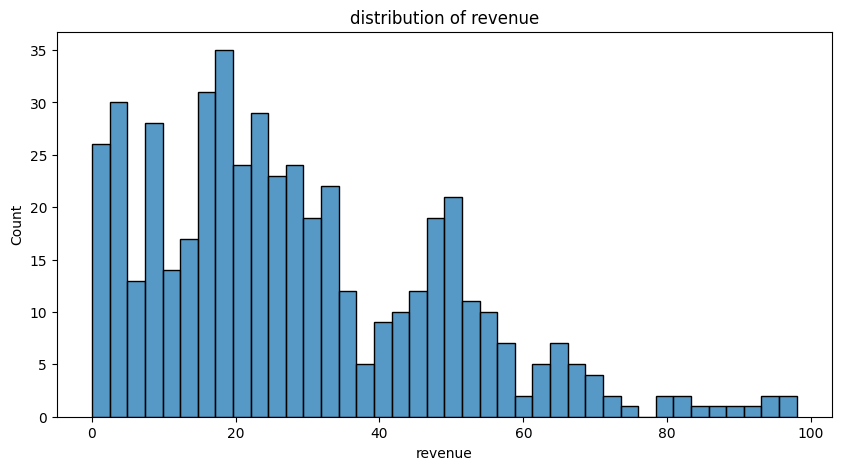

In [12]:
# pharma financials revenue
plt.figure(figsize=(10,5))
sns.histplot(phar_cmpny['revenue_usd_bn'],bins=40)
plt.title("distribution of revenue")
plt.xlabel('revenue')
plt.show()

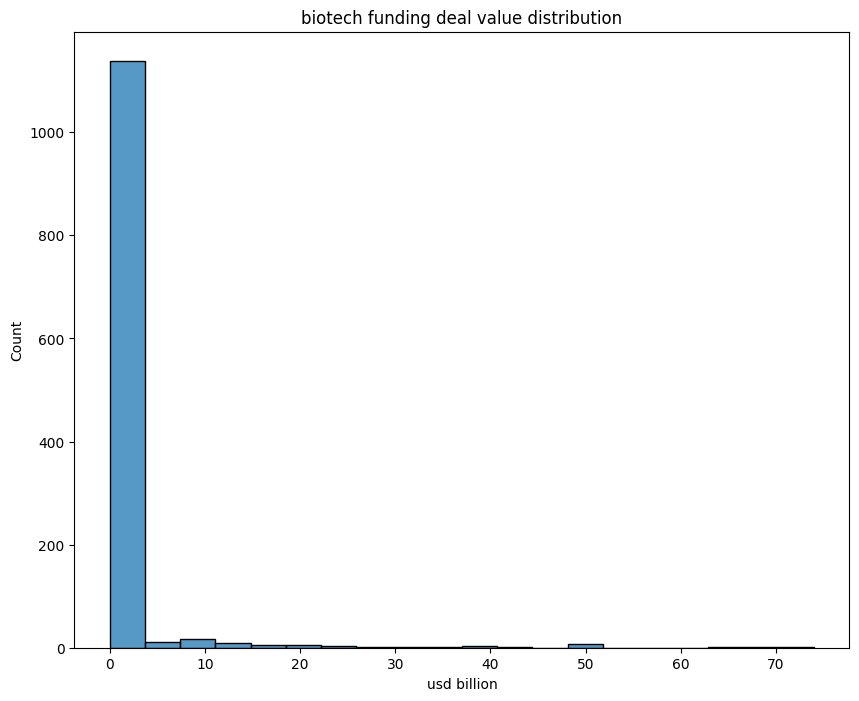

In [13]:
#biotech funding deal value
plt.figure(figsize=(10,8))
sns.histplot(bio_fund['value_usd_bn'],bins=20)
plt.title("biotech funding deal value distribution")
plt.xlabel("usd billion")
plt.show()

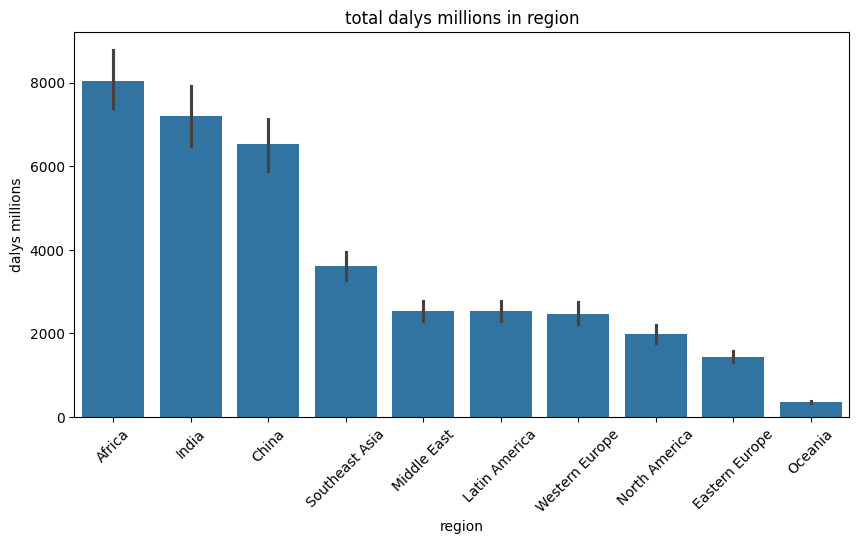

In [14]:

##disease burden dalys millions in regions
plt.figure(figsize=(10,5))

sns.barplot(data=dis_burdn,x='region',y='dalys_millions',estimator=sum,order=dis_burdn.groupby('region')['dalys_millions'].sum().sort_values(ascending=False).index)


plt.title("total dalys millions in region")
plt.xlabel("region")
plt.ylabel("dalys millions")
plt.xticks(rotation=45)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

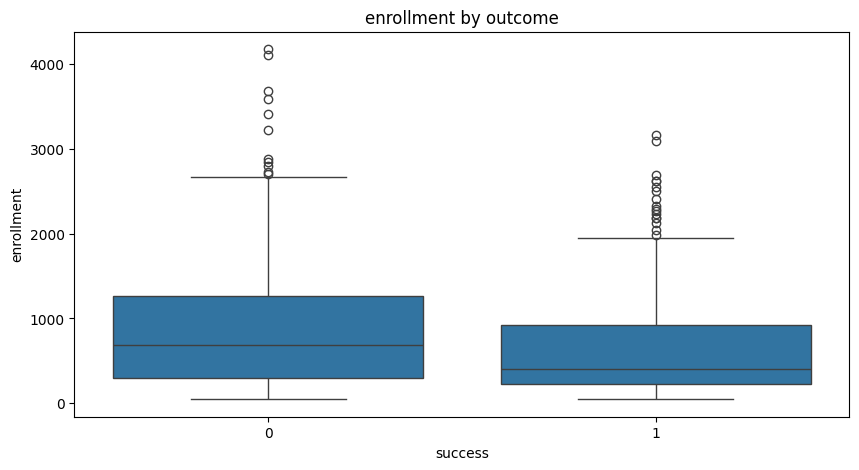

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(data=clin_trial,x='is_success',y='enrollment_n')
plt.title("enrollment by outcome")
plt.xlabel("success")
plt.ylabel("enrollment")
plt.show